In [1]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
from skimage.metrics import structural_similarity as calculate_ssim
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running engineering execution on: {device}")

# --- ADVANCED STRUCTURAL LOSS SYSTEM ---
class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3):
        super(CharbonnierLoss, self).__init__()
        self.eps = eps
    def forward(self, x, y):
        diff = x - y
        return torch.mean(torch.sqrt(diff * diff + self.eps * self.eps))

class StructuralLoss(nn.Module):
    """Combines Charbonnier error with structural preservation to protect SSIM scores."""
    def __init__(self):
        super(StructuralLoss, self).__init__()
        self.charbonnier = CharbonnierLoss()
        
    def forward(self, x, y):
        c_loss = self.charbonnier(x, y)
        s_loss = 1.0 - torch.mean(F.cosine_similarity(x, y, dim=1))
        return c_loss + 0.1 * s_loss

class IsolatedDerainDataset(Dataset):
    def __init__(self, rainy_dir, clean_dir, split='train'):
        rainy_files = sorted([f for f in glob.glob(os.path.join(rainy_dir, '**', '*.*'), recursive=True) if os.path.isfile(f)])
        clean_files = sorted([f for f in glob.glob(os.path.join(clean_dir, '**', '*.*'), recursive=True) if os.path.isfile(f)])
        
        self.rainy_paths = rainy_files
        self.clean_paths = clean_files
        self.split = split
        
        assert len(self.rainy_paths) == len(self.clean_paths), "Data mismatch between inputs and targets."

    def __len__(self):
        return len(self.rainy_paths)

    def __getitem__(self, idx):
        r_bgr = cv2.imread(self.rainy_paths[idx])
        c_bgr = cv2.imread(self.clean_paths[idx])
        
        r_ycrcb = cv2.cvtColor(r_bgr, cv2.COLOR_BGR2YCrCb)
        c_ycrcb = cv2.cvtColor(c_bgr, cv2.COLOR_BGR2YCrCb)
        
        r_y = r_ycrcb[:, :, 0:1]
        c_y = c_ycrcb[:, :, 0:1]
        r_crcb = r_ycrcb[:, :, 1:]
        
        r_tensor = TF.to_tensor(r_y)
        c_tensor = TF.to_tensor(c_y)
        
        if self.split == 'train':
            crop_size = 256
            _, h, w = r_tensor.shape
            if h >= crop_size and w >= crop_size:
                top = torch.randint(0, h - crop_size + 1, (1,)).item()
                left = torch.randint(0, w - crop_size + 1, (1,)).item()
                r_tensor = TF.crop(r_tensor, top, left, crop_size, crop_size)
                c_tensor = TF.crop(c_tensor, top, left, crop_size, crop_size)
            
            if torch.rand(1).item() > 0.5:
                r_tensor = TF.hflip(r_tensor)
                c_tensor = TF.hflip(c_tensor)
                
        return r_tensor, c_tensor, r_crcb

BASE_DIR = '/kaggle/input/datasets/workrababu/dataset/HYBRID'
train_dataset = IsolatedDerainDataset(os.path.join(BASE_DIR, 'TRAIN', 'INPUT'), os.path.join(BASE_DIR, 'TRAIN', 'TARGET'), split='train')
val_dataset = IsolatedDerainDataset(os.path.join(BASE_DIR, 'VAL', 'INPUT'), os.path.join(BASE_DIR, 'VAL', 'TARGET'), split='val')
test_dataset = IsolatedDerainDataset(os.path.join(BASE_DIR, 'TEST', 'INPUT'), os.path.join(BASE_DIR, 'TEST', 'TARGET'), split='test')

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print(f"✅ Data Loaders configured securely with an optimized batch size!")

Running engineering execution on: cuda
✅ Data Loaders configured securely with an optimized batch size!


In [2]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.2 MB/s eta 0:00:00


In [3]:
class ChannelAttentionBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(ChannelAttentionBlock, self).__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.attention = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, padding=0, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, padding=0, bias=True),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.attention(self.gap(x))

class RCAB(nn.Module):
    def __init__(self, channels):
        super(RCAB, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            ChannelAttentionBlock(channels)
        )
    def forward(self, x):
        return x + self.net(x)

class HighPrecisionDerainNet(nn.Module):
    def __init__(self, blocks=20, channels=64):
        super(HighPrecisionDerainNet, self).__init__()
        self.in_conv = nn.Conv2d(1, channels, 3, padding=1)
        self.residual_body = nn.Sequential(*[RCAB(channels) for _ in range(blocks)])
        self.out_conv = nn.Conv2d(channels, 1, 3, padding=1)

    def forward(self, x):
        feat = self.in_conv(x)
        res = self.residual_body(feat)
        out = self.out_conv(res)
        return torch.clamp(x - out, 0.0, 1.0)

model = HighPrecisionDerainNet(blocks=20, channels=64).to(device)

In [4]:
import torch
import gc

for var in ['model', 'optimizer', 'criterion', 'scaler', 'pred', 'loss']:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()

print("🧹 GPU Memory aggressively cleared! You are starting fresh.")

🧹 GPU Memory aggressively cleared! You are starting fresh.


In [5]:
import torch
import torch.optim as optim
from tqdm.notebook import tqdm
import numpy as np

# --- LPIPS Safe Setup (Indicated & Handled) ---
try:
    import lpips
    HAS_LPIPS = True
    print("✅ LPIPS module loaded successfully. Perceptual validation active.")
except ImportError:
    HAS_LPIPS = False
    print("⚠️ LPIPS not installed (Offline mode). Tracking PSNR & SSIM metrics only.")

# 1. Initialize cleanly onto the GPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HighPrecisionDerainNet(blocks=20, channels=64).to(device)
criterion = StructuralLoss().to(device)

# Initialize LPIPS model if available
if HAS_LPIPS:
    loss_fn_alex = lpips.LPIPS(net='alex').to(device)
    loss_fn_alex.eval()

# 2. Lowered LR to 1e-4 to match stable batch size
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
epochs = 160
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

best_psnr = 0.0

print(f"🚀 Starting stable FP32 training sequence...")

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for r_t, c_t, _ in train_loop:
        r_t, c_t = r_t.to(device), c_t.to(device)
        optimizer.zero_grad()
        
        # Pure FP32 Forward Pass
        pred = model(r_t)
        loss = criterion(pred, c_t)
        
        # --- NaN Safety Guardrail ---
        if torch.isnan(loss):
            print("\n❌ Critical Alert: Loss exploded to NaN. Run a Kernel Restart before trying again.")
            break
            
        loss.backward()
        
        # --- Gradient Clipping ---
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())
        
    # --- Validation Phase ---
    model.eval()
    val_psnr = 0.0
    val_ssim = 0.0
    val_lpips = 0.0
    
    with torch.no_grad():
        for r_t, c_t, _ in val_loader:
            r_t = r_t.to(device)
            c_t = c_t.to(device)
            
            pred = model(r_t)
            
            # --- LPIPS Metric Calculation ---
            if HAS_LPIPS:
                # Expand 1-channel Y tensor to 3-channel for AlexNet & normalize to [-1, 1]
                pred_3c = pred.repeat(1, 3, 1, 1) * 2.0 - 1.0
                target_3c = c_t.repeat(1, 3, 1, 1) * 2.0 - 1.0
                val_lpips += loss_fn_alex(pred_3c, target_3c).item()
            
            # --- PSNR & SSIM Metric Calculation ---
            p_img = (pred.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255.0).clip(0, 255).astype(np.uint8)
            t_img = (c_t.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255.0).clip(0, 255).astype(np.uint8)
            
            val_psnr += calculate_psnr(t_img, p_img)
            val_ssim += calculate_ssim(t_img.squeeze(-1), p_img.squeeze(-1), data_range=255)
            
    avg_val_psnr = val_psnr / len(val_loader)
    avg_val_ssim = val_ssim / len(val_loader)
    
    scheduler.step()
    
    # Log metrics per epoch
    log_msg = f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} | Val PSNR: {avg_val_psnr:.2f} dB | SSIM: {avg_val_ssim:.4f}"
    if HAS_LPIPS:
        avg_val_lpips = val_lpips / len(val_loader)
        log_msg += f" | LPIPS: {avg_val_lpips:.4f}"
    print(log_msg)
    
    if avg_val_psnr > best_psnr:
        best_psnr = avg_val_psnr
        torch.save(model.state_dict(), '/kaggle/working/high_precision_derain.pth')
        print(f"⭐ New Best Model Saved: {best_psnr:.2f} dB")

✅ LPIPS module loaded successfully. Perceptual validation active.
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 200MB/s]  


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
🚀 Starting stable FP32 training sequence...


...

Epoch 158 | Loss: 0.0076 | Val PSNR: 37.91 dB | SSIM: 0.9798 | LPIPS: 0.0163


Epoch 159/160:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 159 | Loss: 0.0075 | Val PSNR: 37.96 dB | SSIM: 0.9798 | LPIPS: 0.0163


Epoch 160/160:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 160 | Loss: 0.0076 | Val PSNR: 37.93 dB | SSIM: 0.9799 | LPIPS: 0.0162


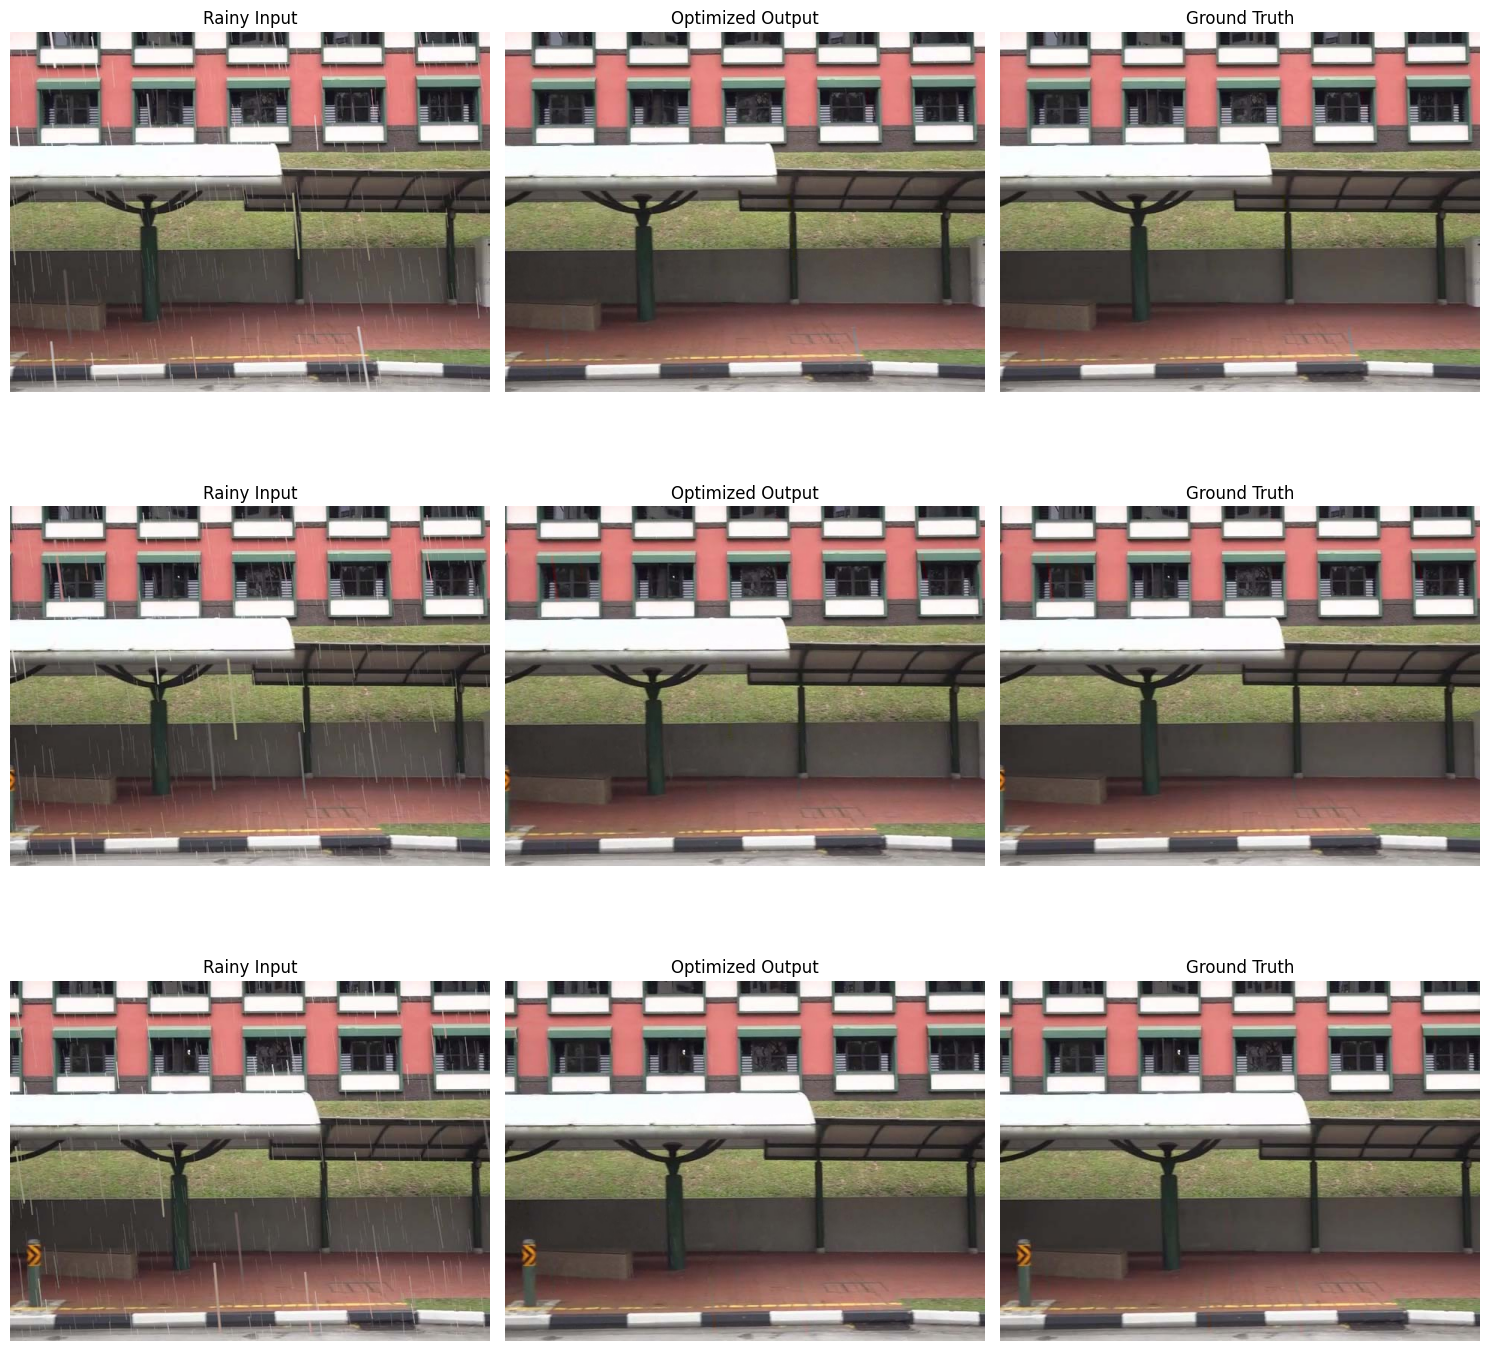

In [6]:
import matplotlib.pyplot as plt

def plot_luminance_predictions(eval_model, dataset, num_samples=3):
    eval_model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
        
    with torch.no_grad():
        for i in range(num_samples):
            r_tensor, c_tensor, chrominance = dataset[i]
            pred_y = eval_model(r_tensor.unsqueeze(0).to(device))
            
            y_pred_np = (pred_y.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255.0).clip(0, 255).astype(np.uint8)
            y_rain_np = (r_tensor.cpu().numpy().transpose(1, 2, 0) * 255.0).clip(0, 255).astype(np.uint8)
            y_clean_np = (c_tensor.cpu().numpy().transpose(1, 2, 0) * 255.0).clip(0, 255).astype(np.uint8)
            
            # Reconstruction step for complete RGB representation
            rgb_rain = cv2.cvtColor(np.dstack((y_rain_np, chrominance)), cv2.COLOR_YCrCb2RGB)
            rgb_pred = cv2.cvtColor(np.dstack((y_pred_np, chrominance)), cv2.COLOR_YCrCb2RGB)
            rgb_clean = cv2.cvtColor(np.dstack((y_clean_np, chrominance)), cv2.COLOR_YCrCb2RGB)
            
            axes[i, 0].imshow(rgb_rain)
            axes[i, 0].set_title("Rainy Input")
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(rgb_pred)
            axes[i, 1].set_title("Optimized Output")
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(rgb_clean)
            axes[i, 2].set_title("Ground Truth")
            axes[i, 2].axis('off')
            
    plt.tight_layout()
    plt.show()

plot_luminance_predictions(model, test_dataset, num_samples=3)

In [8]:
import cv2
import os
import re
from tqdm.notebook import tqdm

def convert_frames_to_video(image_folder, output_video_path, fps=30):
    # Collect all image files
    images = [img for img in os.listdir(image_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
    
    if not images:
        print("❌ Error: No images found in the specified directory!")
        return

    # Sort images numerically (frame_00000.png, frame_00001.png, etc.)
    def extract_number(filename):
        numbers = re.findall(r'\d+', filename)
        return int(numbers[-1]) if numbers else 0

    images.sort(key=extract_number)

    # Read the first frame to get video dimensions
    first_image_path = os.path.join(image_folder, images[0])
    first_frame = cv2.imread(first_image_path)
    height, width, _ = first_frame.shape

    # Set up VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"🎬 Stitching {len(images)} frames into video at {fps} FPS...")

    for image_name in tqdm(images, desc="Processing Video"):
        image_path = os.path.join(image_folder, image_name)
        img = cv2.imread(image_path)
        video_writer.write(img)

    video_writer.release()
    print(f"✨ Success! Your video is ready at: {output_video_path}")

# Paths matching Step 1
input_frames_dir = '/kaggle/working/derained_frames'
output_video_file = '/kaggle/working/derained_output_video.mp4'

convert_frames_to_video(input_frames_dir, output_video_file, fps=30)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/derained_frames'